<a href="https://colab.research.google.com/github/danielhbbarbosa/mba-ai/blob/main/ai-for-churn-risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e Modelagem de Churn

Este notebook tem como objetivo realizar uma análise completa de um dataset, desde a carga dos dados até a construção de um modelo de machine learning para prever churn, incluindo uma interface interativa para previsões.

## 1. Carga Automática do Dataset e Exploração Inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, mean_squared_error, mean_absolute_error, r2_score, roc_curve
import joblib
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, FloatText, IntText, Button, Output
import warnings
warnings.filterwarnings('ignore')

# Caminho do arquivo de dados (anexado pelo usuário)
file_path = '/content/Aula11_Churn.xlsx'

# Detectar o tipo de arquivo e carregar o dataset
def load_dataset(file_path):
    if file_path.endswith('.csv'):
        return pd.read_csv(file_path)
    elif file_path.endswith(('.xls', '.xlsx')):
        return pd.read_excel(file_path)
    elif file_path.endswith('.parquet'):
        return pd.read_parquet(file_path)
    else:
        raise ValueError("Formato de arquivo não suportado. Por favor, forneça um CSV, Excel ou Parquet.")

try:
    df = load_dataset(file_path)
    print("Dataset carregado com sucesso!")
    print("\nShape do dataset:", df.shape)
    print("\nTipos de dados e valores não-nulos:")
    df.info()
    print("\nPrimeiras 5 linhas do dataset:")
    display(df.head())
    print("\nColunas do dataset:", df.columns.tolist())
except Exception as e:
    print(f"Erro ao carregar o dataset: {e}")

Dataset carregado com sucesso!

Shape do dataset: (250, 5)

Tipos de dados e valores não-nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Cliente            250 non-null    object
 1   Frequencia_Uso_Horas  250 non-null    int64 
 2   Tickets_Bug           250 non-null    int64 
 3   NPS                   250 non-null    int64 
 4   Churn                 250 non-null    object
dtypes: int64(3), object(2)
memory usage: 9.9+ KB

Primeiras 5 linhas do dataset:


,ID_Cliente,Frequencia_Uso_Horas,Tickets_Bug,NPS,Churn
0,CLI-001,37,1,0,Não
1,CLI-002,95,2,10,Não
2,CLI-003,73,4,6,Sim
3,CLI-004,60,2,7,Não
4,CLI-005,16,5,2,Sim



Colunas do dataset: ['ID_Cliente', 'Frequencia_Uso_Horas', 'Tickets_Bug', 'NPS', 'Churn']


## 2. Definição da Variável Alvo

Variável alvo identificada automaticamente: 'Churn'
O problema é de **classification** (variável alvo 'Churn' é categórica).

Distribuição da variável alvo:


,count
Churn,
Não,174
Sim,76


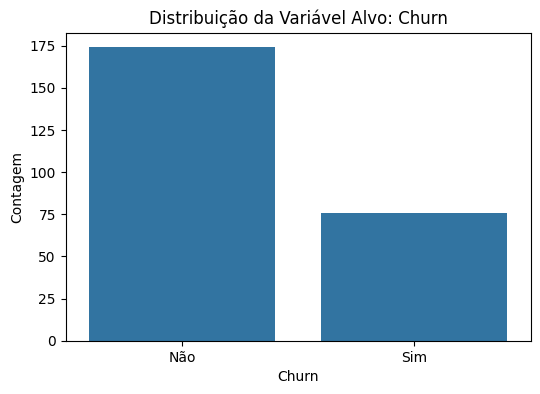

In [ ]:
# Função para identificar a variável alvo
def identify_target_variable(df):
    common_target_names = ['churn', 'y', 'label', 'classe']
    for col in df.columns:
        if col.lower() in common_target_names:
            print(f"Variável alvo identificada automaticamente: '{col}'")
            return col
    return None

target_column = identify_target_variable(df)

if target_column is None:
    print("Nenhuma variável alvo comum foi encontrada. Por favor, especifique a coluna alvo.")
    # Usar um widget para pedir ao usuário para selecionar a coluna alvo
    target_selector = widgets.Dropdown(
        options=df.columns.tolist(),
        description='Coluna Alvo:',
        disabled=False,
    )
    display(target_selector)

    # Quando o usuário selecionar, armazenar a escolha
    def on_target_select(change):
        global target_column
        target_column = change.new
        print(f"Variável alvo selecionada: '{target_column}'")

    target_selector.observe(on_target_select, names='value')
else:
    y = df[target_column]
    X = df.drop(columns=[target_column])

    # Determinar se é um problema de classificação ou regressão
    if pd.api.types.is_numeric_dtype(y) and y.nunique() <= 50 and y.nunique() > 1:
        # Heurística: poucos valores únicos para um tipo numérico pode indicar classificação
        problem_type = 'classification'
        print(f"O problema é de **{problem_type}** (variável alvo '{target_column}' é numérica com {y.nunique()} valores únicos).")
    elif pd.api.types.is_object_dtype(y) or pd.api.types.is_string_dtype(y):
        problem_type = 'classification'
        print(f"O problema é de **{problem_type}** (variável alvo '{target_column}' é categórica).")
    else:
        problem_type = 'regression'
        print(f"O problema é de **{problem_type}** (variável alvo '{target_column}' é numérica contínua).")

    print("\nDistribuição da variável alvo:")
    if problem_type == 'classification':
        display(y.value_counts())
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y)
        plt.title(f'Distribuição da Variável Alvo: {target_column}')
        plt.xlabel(target_column)
        plt.ylabel('Contagem')
        plt.show()
    else:
        print(y.describe())
        plt.figure(figsize=(8, 5))
        sns.histplot(y, kde=True)
        plt.title(f'Distribuição da Variável Alvo: {target_column}')
        plt.xlabel(target_column)
        plt.ylabel('Frequência')
        plt.show()

## 3. Análise Exploratória de Dados (EDA)


Estatísticas Descritivas:


,ID_Cliente,Frequencia_Uso_Horas,Tickets_Bug,NPS,Churn
count,250,250.000000,250.000000,250.000000,250
unique,250,NaN,NaN,NaN,2
top,CLI-001,NaN,NaN,NaN,Não
freq,1,NaN,NaN,NaN,174
mean,NaN,49.056000,1.864000,5.132000,NaN
std,NaN,29.741403,1.410483,3.249123,NaN
min,NaN,1.000000,0.000000,0.000000,NaN
25%,NaN,23.250000,1.000000,2.000000,NaN
50%,NaN,50.000000,2.000000,5.500000,NaN
75%,NaN,75.750000,3.000000,8.000000,NaN



Valores Ausentes por Coluna:


,Missing Count,Missing Percent (%)



Cardinalidade das Variáveis Categóricas:

Distribuição e Outliers das Variáveis Numéricas:


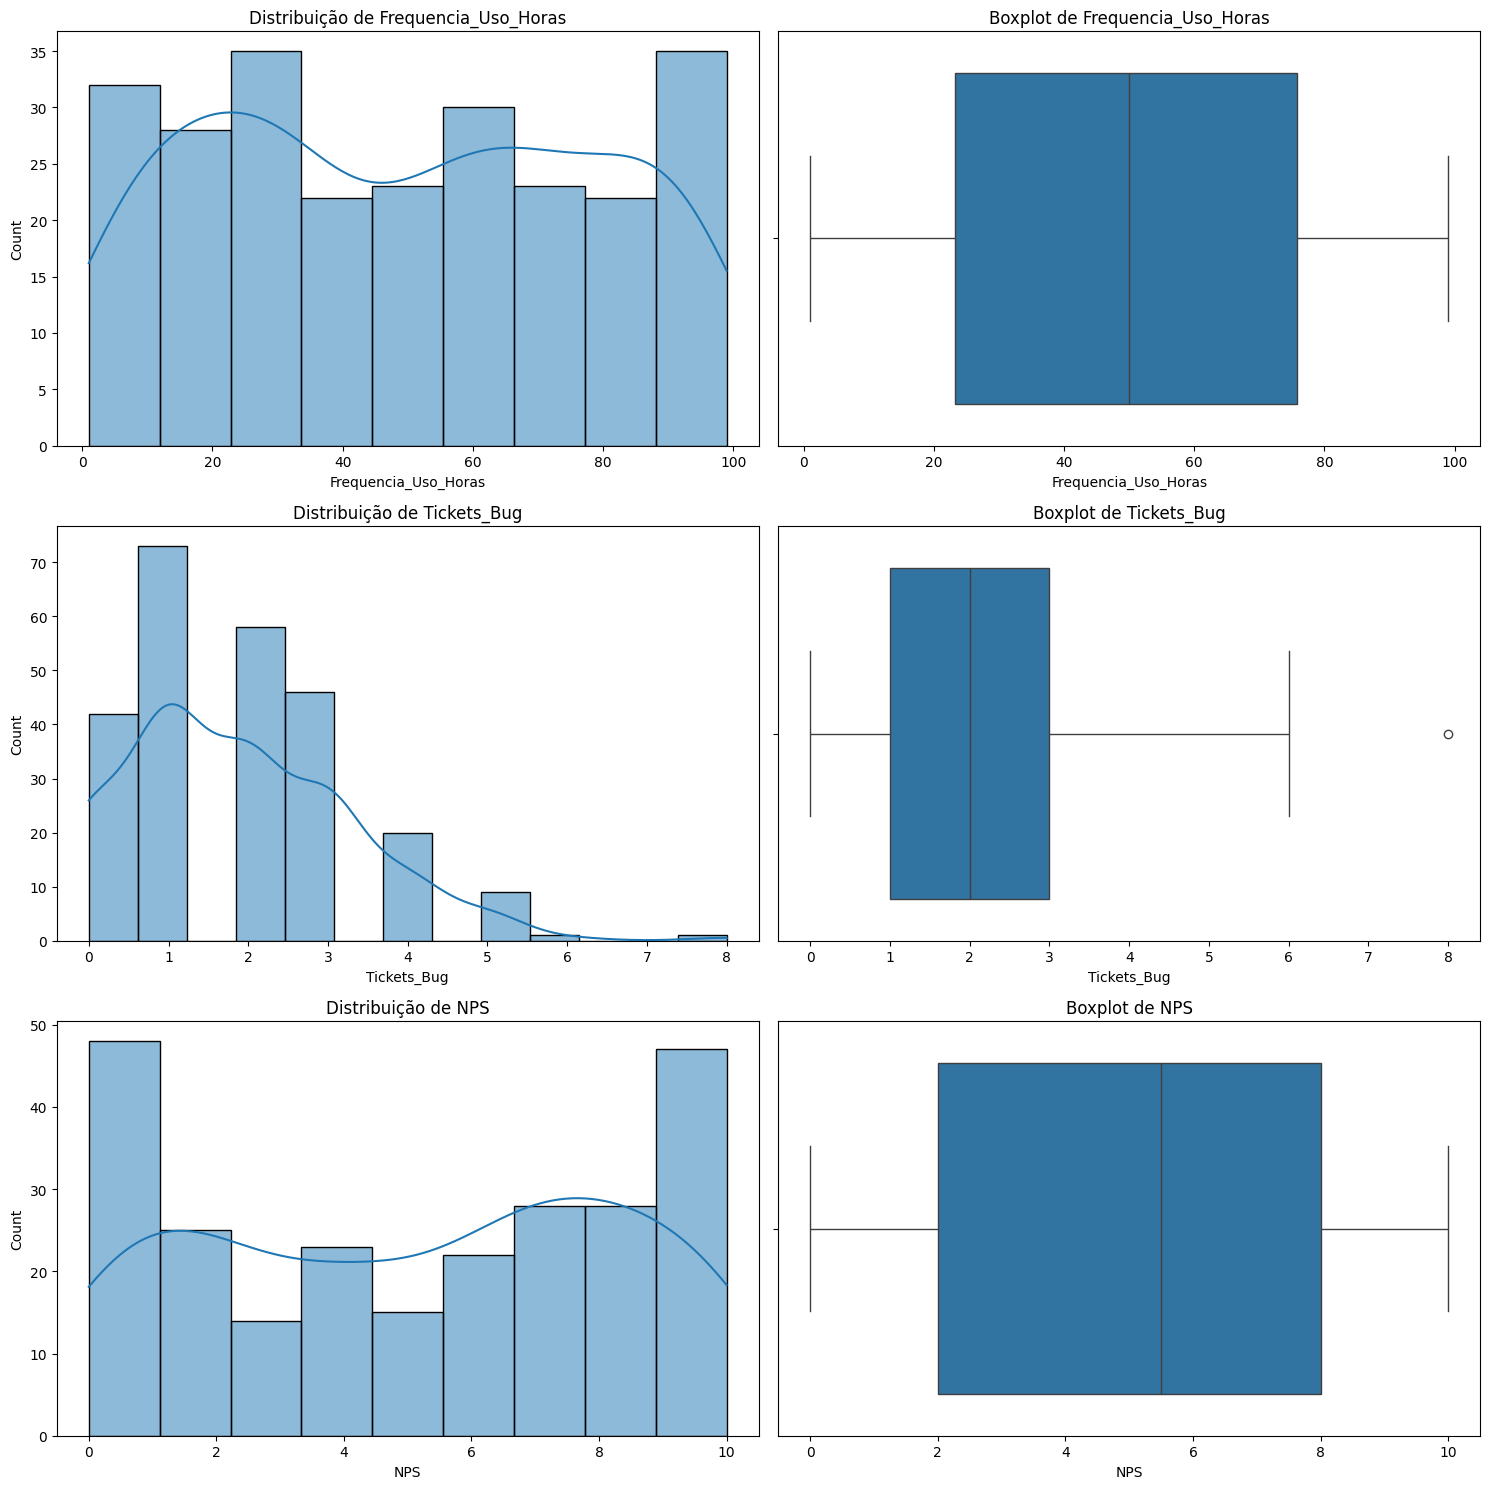


Matriz de Correlação das Variáveis Numéricas:


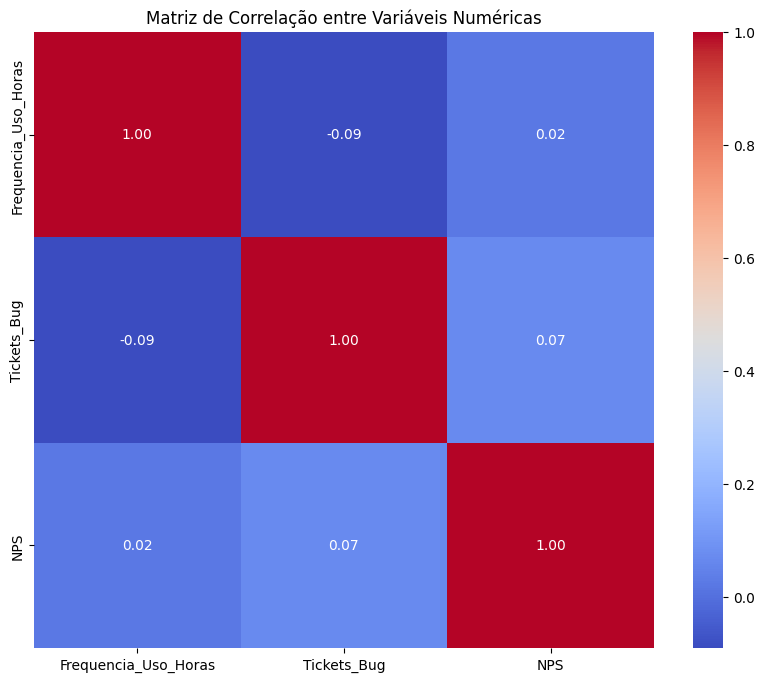

In [ ]:
print("\nEstatísticas Descritivas:")
display(df.describe(include='all'))

print("\nValores Ausentes por Coluna:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percent (%)': missing_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percent (%)', ascending=False))

print("\nCardinalidade das Variáveis Categóricas:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if target_column in categorical_cols:
    categorical_cols.remove(target_column)
if 'ID_Cliente' in categorical_cols: # Assuming ID_Cliente is just an identifier and not a feature
    categorical_cols.remove('ID_Cliente')

for col in categorical_cols:
    print(f"- {col}: {df[col].nunique()} valores únicos")
    if df[col].nunique() < 20: # Display value counts for columns with fewer unique values
        print(df[col].value_counts())
    print("\n")

print("\nDistribuição e Outliers das Variáveis Numéricas:")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 5 * len(numerical_cols)))
for i, col in enumerate(numerical_cols):
    if col != target_column: # Avoid plotting target if it's numeric and already plotted
        # Histograma
        plt.subplot(len(numerical_cols), 2, 2*i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribuição de {col}')

        # Boxplot para Outliers
        plt.subplot(len(numerical_cols), 2, 2*i + 2)
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

print("\nMatriz de Correlação das Variáveis Numéricas:")
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

## 4. Pré-processamento (Pipeline do scikit-learn)

In [ ]:
# Separar X e y
X = df.drop(columns=[target_column, 'ID_Cliente'])
y = df[target_column]

# Identificar colunas numéricas e categóricas
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Criar pipelines de pré-processamento
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Criar um ColumnTransformer para aplicar diferentes transformações a diferentes colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir os dados em conjuntos de treino e teste
# Estratificar se for classificação
if problem_type == 'classification':
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Pré-processamento configurado e dados divididos em treino e teste.")
print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

Pré-processamento configurado e dados divididos em treino e teste.
Shape de X_train: (200, 3)
Shape de X_test: (50, 3)
Shape de y_train: (200,)
Shape de y_test: (50,)


## 5. Treinar 3 Modelos Genéricos Baseados em Árvore e Comparar

In [ ]:
# Dicionários para armazenar modelos e resultados
models = {}
results = {'Model': [], 'Best_Params': [], 'Train_Score': [], 'Test_Score': [], 'Metric_Name': []}

# Definir os modelos e seus respectivos parâmetros para GridSearchCV
if problem_type == 'classification':
    # Classificadores
    model_configs = {
        'Decision Tree Classifier': {
            'model': DecisionTreeClassifier(random_state=42),
            'params': {
                'model__max_depth': [3, 5, 7, None],
                'model__min_samples_split': [2, 5, 10]
            },
            'scoring': 'f1_weighted' # Usar f1_weighted para classes desbalanceadas ou multiclass
        },
        'Random Forest Classifier': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [5, 10, None]
            },
            'scoring': 'f1_weighted'
        },
        'Gradient Boosting Classifier': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'model__n_estimators': [50, 100, 200],
                'model__learning_rate': [0.01, 0.1, 0.2],
                'model__max_depth': [3, 5]
            },
            'scoring': 'f1_weighted'
        }
    }
else:
    # Regressores
    model_configs = {
        'Decision Tree Regressor': {
            'model': DecisionTreeRegressor(random_state=42),
            'params': {
                'model__max_depth': [3, 5, 7, None],
                'model__min_samples_split': [2, 5, 10]
            },
            'scoring': 'neg_mean_squared_error'
        },
        'Random Forest Regressor': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [5, 10, None]
            },
            'scoring': 'neg_mean_squared_error'
        },
        'Gradient Boosting Regressor': {
            'model': GradientBoostingRegressor(random_state=42),
            'params': {
                'model__n_estimators': [50, 100, 200],
                'model__learning_rate': [0.01, 0.1, 0.2],
                'model__max_depth': [3, 5]
            },
            'scoring': 'neg_mean_squared_error'
        }
    }

# Treinar e avaliar cada modelo
for model_name, config in model_configs.items():
    print(f"\n{'='*50}\nTreinando {model_name}...\n{'='*50}")

    # Criar pipeline completo (pré-processamento + modelo)
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', config['model'])])

    # Configurar GridSearchCV
    grid_search = GridSearchCV(full_pipeline, config['params'], cv=5,
                               scoring=config['scoring'], n_jobs=-1, verbose=1)

    # Ajustar o modelo aos dados de treino
    grid_search.fit(X_train, y_train)

    # Armazenar o melhor modelo
    best_model = grid_search.best_estimator_
    models[model_name] = best_model

    print(f"Melhores hiperparâmetros para {model_name}: {grid_search.best_params_}")

    # Avaliar o modelo nos dados de treino e teste
    if problem_type == 'classification':
        train_preds = best_model.predict(X_train)
        test_preds = best_model.predict(X_test)

        train_score = f1_score(y_train, train_preds, average='weighted')
        test_score = f1_score(y_test, test_preds, average='weighted')
        metric_name = 'F1-Score (Weighted)'

    else: # Regression
        train_preds = best_model.predict(X_train)
        test_preds = best_model.predict(X_test)

        train_score = mean_squared_error(y_train, train_preds, squared=False) # RMSE
        test_score = mean_squared_error(y_test, test_preds, squared=False) # RMSE
        metric_name = 'RMSE'

    print(f"Performance de treino ({metric_name}): {train_score:.4f}")
    print(f"Performance de teste ({metric_name}): {test_score:.4f}")

    results['Model'].append(model_name)
    results['Best_Params'].append(grid_search.best_params_)
    results['Train_Score'].append(train_score)
    results['Test_Score'].append(test_score)
    results['Metric_Name'].append(metric_name)

# Exibir resumo dos modelos
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Test_Score', ascending=(problem_type=='regression')))


Treinando Decision Tree Classifier...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores hiperparâmetros para Decision Tree Classifier: {'model__max_depth': 3, 'model__min_samples_split': 2}
Performance de treino (F1-Score (Weighted)): 0.7823
Performance de teste (F1-Score (Weighted)): 0.6969

Treinando Random Forest Classifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Melhores hiperparâmetros para Random Forest Classifier: {'model__max_depth': 5, 'model__n_estimators': 50}
Performance de treino (F1-Score (Weighted)): 0.8605
Performance de teste (F1-Score (Weighted)): 0.7123

Treinando Gradient Boosting Classifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Melhores hiperparâmetros para Gradient Boosting Classifier: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Performance de treino (F1-Score (Weighted)): 0.8361
Performance de teste (F1-Score (Weighted)): 0.6528


,Model,Best_Params,Train_Score,Test_Score,Metric_Name
1,Random Forest Classifier,"{'model__max_depth': 5, 'model__n_estimators':...",0.860467,0.712253,F1-Score (Weighted)
0,Decision Tree Classifier,"{'model__max_depth': 3, 'model__min_samples_sp...",0.782305,0.696940,F1-Score (Weighted)
2,Gradient Boosting Classifier,"{'model__learning_rate': 0.01, 'model__max_dep...",0.836102,0.652803,F1-Score (Weighted)


## 6. Avaliação no Teste


### Avaliação Detalhada dos Modelos no Conjunto de Teste ###

Avaliação do Decision Tree Classifier
Acurácia: 0.7000
F1-Score (Weighted): 0.6969
Matriz de Confusão:
[[28  7]
 [ 8  7]]
ROC-AUC: 0.7229


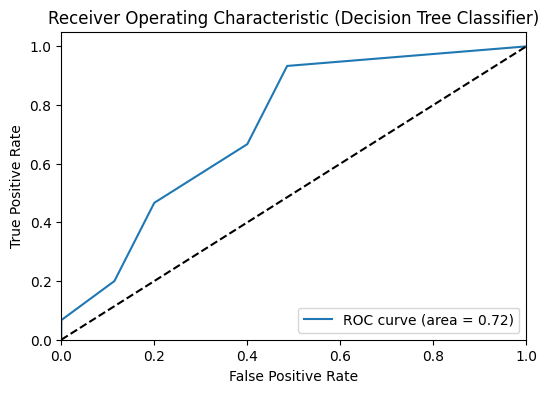


Avaliação do Random Forest Classifier
Acurácia: 0.7400
F1-Score (Weighted): 0.7123
Matriz de Confusão:
[[32  3]
 [10  5]]
ROC-AUC: 0.7686


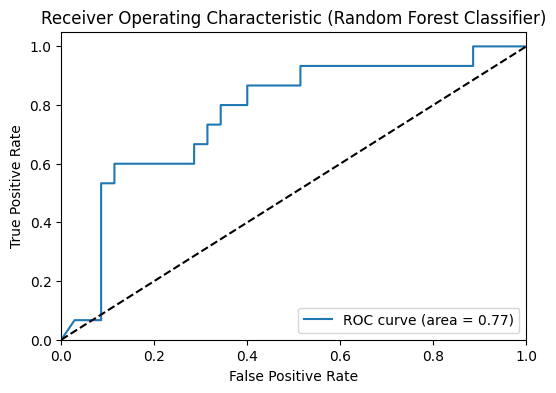


Avaliação do Gradient Boosting Classifier
Acurácia: 0.7000
F1-Score (Weighted): 0.6528
Matriz de Confusão:
[[32  3]
 [12  3]]
ROC-AUC: 0.8086


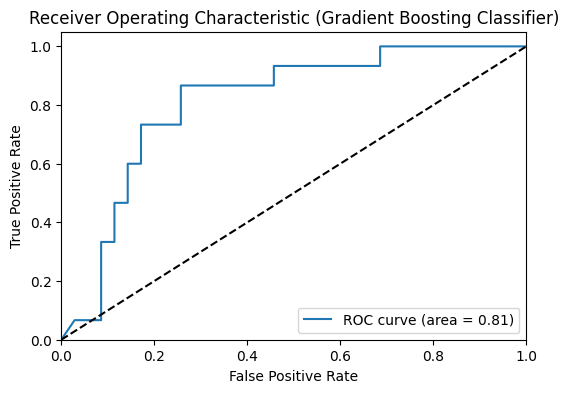


Melhor modelo identificado: Random Forest Classifier com Test_Score de 0.7123


In [ ]:
print("\n### Avaliação Detalhada dos Modelos no Conjunto de Teste ###")

best_model_name = results_df.loc[results_df['Test_Score'].idxmin() if problem_type == 'regression' else results_df['Test_Score'].idxmax(), 'Model']
best_score = results_df.loc[results_df['Test_Score'].idxmin() if problem_type == 'regression' else results_df['Test_Score'].idxmax(), 'Test_Score']

for model_name, model_pipeline in models.items():
    print(f"\n{'='*50}\nAvaliação do {model_name}\n{'='*50}")

    y_pred = model_pipeline.predict(X_test)

    if problem_type == 'classification':
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        print(f"Acurácia: {accuracy:.4f}")
        print(f"F1-Score (Weighted): {f1:.4f}")
        print("Matriz de Confusão:")
        print(cm)

        # ROC-AUC para classificação binária
        if len(y.unique()) == 2:
            # Obter as probabilidades para a classe positiva
            y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            print(f"ROC-AUC: {roc_auc:.4f}")

            # Plotar curva ROC
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=model_pipeline.classes_[1])
            plt.figure(figsize=(6, 4))
            plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'Receiver Operating Characteristic ({model_name})')
            plt.legend(loc="lower right")
            plt.show()

    else: # Regression
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"RMSE: {rmse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")

print(f"\n{'='*50}\nMelhor modelo identificado: {best_model_name} com Test_Score de {best_score:.4f}\n{'='*50}")


## 7. Escolha do Melhor Modelo e Explicação

O melhor modelo, com base na métrica de teste 'F1-Score (Weighted)', é: **Random Forest Classifier**
Score de teste (F1-Score (Weighted)): 0.7123

### O que o modelo aprendeu e sua confiabilidade: ###
O modelo 'Random Forest Classifier' foi treinado para prever se um cliente irá ou não ter churn. Ele aprendeu padrões nas características dos clientes (como frequência de uso, tickets de bug e NPS) que o ajudam a diferenciar entre clientes que ficam e clientes que saem.
A confiabilidade é indicada pelo seu F1-Score (Weighted), que considera tanto a precisão quanto a completude das previsões, sendo especialmente útil quando as classes estão desbalanceadas. Um score alto indica que o modelo é bom em identificar ambas as classes.
O modelo pode errar em casos de clientes com características ambíguas ou em situações onde os dados de treino não representaram bem a realidade. Clientes 'na fronteira' entre churn e não-churn são os mais difíceis de prever.

### Variáveis mais influentes (Feature I

,Feature,Importance
0,num__Frequencia_Uso_Horas,0.360036
1,num__Tickets_Bug,0.329913
2,num__NPS,0.310050


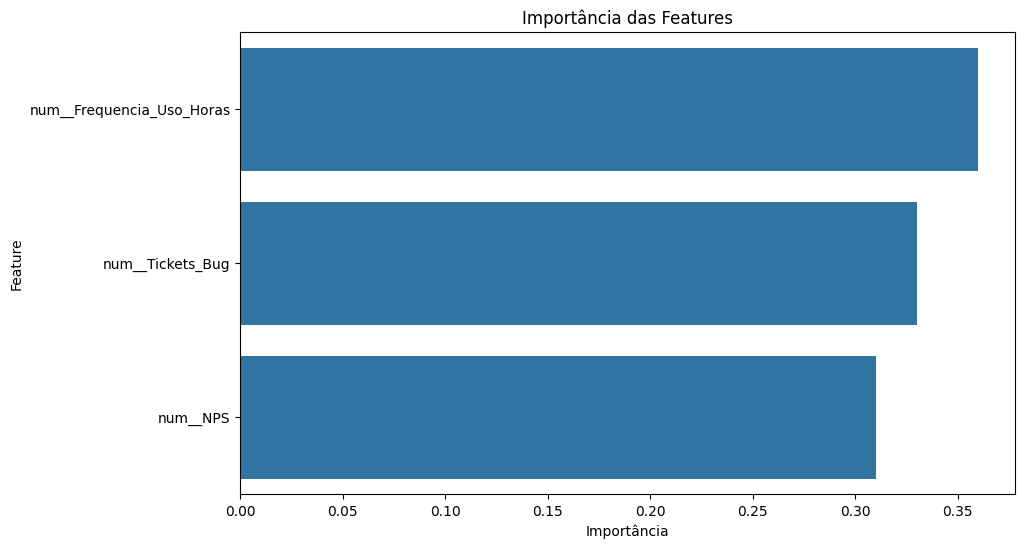

In [ ]:
# Determinar o melhor modelo
if problem_type == 'classification':
    best_model_name = results_df.sort_values(by='Test_Score', ascending=False).iloc[0]['Model']
    best_model_pipeline = models[best_model_name]
    main_metric = 'F1-Score (Weighted)'
else:
    best_model_name = results_df.sort_values(by='Test_Score', ascending=True).iloc[0]['Model']
    best_model_pipeline = models[best_model_name]
    main_metric = 'RMSE'

print(f"O melhor modelo, com base na métrica de teste '{main_metric}', é: **{best_model_name}**")
print(f"Score de teste ({main_metric}): {results_df[results_df['Model'] == best_model_name]['Test_Score'].values[0]:.4f}")

print("\n### O que o modelo aprendeu e sua confiabilidade: ###")
if problem_type == 'classification':
    print(f"O modelo '{best_model_name}' foi treinado para prever se um cliente irá ou não ter churn. Ele aprendeu padrões nas características dos clientes (como frequência de uso, tickets de bug e NPS) que o ajudam a diferenciar entre clientes que ficam e clientes que saem.")
    print("A confiabilidade é indicada pelo seu F1-Score (Weighted), que considera tanto a precisão quanto a completude das previsões, sendo especialmente útil quando as classes estão desbalanceadas. Um score alto indica que o modelo é bom em identificar ambas as classes.")
    print("O modelo pode errar em casos de clientes com características ambíguas ou em situações onde os dados de treino não representaram bem a realidade. Clientes 'na fronteira' entre churn e não-churn são os mais difíceis de prever.")
else:
    print(f"O modelo '{best_model_name}' foi treinado para prever um valor numérico contínuo, utilizando as outras características do dataset. Ele identificou relações entre as features e o valor da variável alvo.")
    print("A confiabilidade é medida pelo RMSE (Root Mean Squared Error) e R². O RMSE indica a magnitude média dos erros do modelo, enquanto o R² mostra a proporção da variância na variável alvo que é previsível a partir das variáveis independentes. Um RMSE menor e um R² maior indicam um modelo mais confiável.")
    print("O modelo pode errar em previsões de valores extremos ou em situações que não foram bem representadas nos dados de treino.")

print("\n### Variáveis mais influentes (Feature Importance): ###")
# Tentar extrair feature importance do melhor modelo
# Acesso aos nomes das features após o pré-processamento
feature_names = best_model_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Obter o modelo final (DecisionTree, RandomForest, GradientBoosting) dentro da pipeline
final_model = best_model_pipeline.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("Top 5 variáveis mais influentes:")
    display(feature_importance_df.head())

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
    plt.title('Importância das Features')
    plt.xlabel('Importância')
    plt.ylabel('Feature')
    plt.show()
else:
    print("O melhor modelo não possui um atributo 'feature_importances_'.")


## 8. Interface de Usuário para Previsão (UI com `ipywidgets`)

In [ ]:
# Pegar o melhor modelo e a pipeline de pré-processamento
best_model_pipeline = models[best_model_name]

# Criar widgets para cada feature
input_widgets = {}

# Obter os dados originais para determinar os ranges e opções para os widgets
# Usar X (sem a coluna alvo) para obter os tipos de dados originais

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        min_val = X[col].min()
        max_val = X[col].max()
        # Usar FloatText para flexibilidade, mas pode ser IntText se preferir
        input_widgets[col] = widgets.FloatText(
            value=(min_val + max_val) / 2,
            description=f'{col}:',
            min=min_val,
            max=max_val,
            step=1.0 if pd.api.types.is_integer_dtype(X[col]) else 0.1,
            disabled=False
        )
    elif pd.api.types.is_object_dtype(X[col]) or pd.api.types.is_string_dtype(X[col]):
        options = list(X[col].unique())
        input_widgets[col] = widgets.Dropdown(
            options=options,
            value=options[0],
            description=f'{col}:',
            disabled=False,
        )

# Botão de Previsão
predict_button = widgets.Button(description="Prever")
output_widget = widgets.Output()

def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        # Coletar os valores dos widgets
        input_data = {col: widget.value for col, widget in input_widgets.items()}
        input_df = pd.DataFrame([input_data])

        # Fazer a previsão
        prediction = best_model_pipeline.predict(input_df)

        if problem_type == 'classification':
            print(f"Previsão de {target_column}: {prediction[0]}")
            # Se for classificação binária, mostrar probabilidade
            if len(y.unique()) == 2:
                proba = best_model_pipeline.predict_proba(input_df)[0]
                class_labels = best_model_pipeline.classes_
                print(f"Probabilidade de {class_labels[0]}: {proba[0]:.2f}")
                print(f"Probabilidade de {class_labels[1]}: {proba[1]:.2f}")
        else:
            print(f"Previsão de {target_column}: {prediction[0]:.2f}")

predict_button.on_click(on_predict_button_clicked)

# Organizar os widgets na interface
ui_widgets = widgets.VBox(list(input_widgets.values()) + [predict_button, output_widget])
display(ui_widgets)


## 9. Salvando e Recarregando o Modelo

In [ ]:
# Salvar o melhor modelo treinado
model_filename = f'best_model_pipeline_{problem_type}.joblib'
joblib.dump(best_model_pipeline, model_filename)
print(f"Modelo salvo como '{model_filename}'")

# Recarregar o modelo para demonstração
print(f"\nRecarregando o modelo '{model_filename}'...")
loaded_model_pipeline = joblib.load(model_filename)
print("Modelo recarregado com sucesso!")

# Exemplo de previsão com o modelo recarregado
print("\nExemplo de previsão com o modelo recarregado:")
# Pegar uma amostra do conjunto de teste
sample_input = X_test.head(1)
display(sample_input)

reloaded_prediction = loaded_model_pipeline.predict(sample_input)

if problem_type == 'classification':
    print(f"Previsão recarregada de {target_column}: {reloaded_prediction[0]}")
    if len(y.unique()) == 2:
        reloaded_proba = loaded_model_pipeline.predict_proba(sample_input)[0]
        class_labels = loaded_model_pipeline.classes_
        print(f"Probabilidade de {class_labels[0]}: {reloaded_proba[0]:.2f}")
        print(f"Probabilidade de {class_labels[1]}: {reloaded_proba[1]:.2f}")
else:
    print(f"Previsão recarregada de {target_column}: {reloaded_prediction[0]:.2f}")

print("\n--- Análise e Modelagem Concluídas --- ")
print("O notebook foi concluído. Você pode agora interagir com a UI de previsão ou usar o modelo salvo.")

Modelo salvo como 'best_model_pipeline_classification.joblib'

Recarregando o modelo 'best_model_pipeline_classification.joblib'...
Modelo recarregado com sucesso!

Exemplo de previsão com o modelo recarregado:


,Frequencia_Uso_Horas,Tickets_Bug,NPS
109,8,2,6


Previsão recarregada de Churn: Não
Probabilidade de Não: 0.80
Probabilidade de Sim: 0.20

--- Análise e Modelagem Concluídas --- 
O notebook foi concluído. Você pode agora interagir com a UI de previsão ou usar o modelo salvo.


## 8. Interface de Usuário para Previsão (UI com `ipywidgets`)

In [ ]:
# Pegar o melhor modelo e a pipeline de pré-processamento
best_model_pipeline = models[best_model_name]

# Criar widgets para cada feature
input_widgets = {}

# Obter os dados originais para determinar os ranges e opções para os widgets
# Usar X (sem a coluna alvo) para obter os tipos de dados originais

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        min_val = X[col].min()
        max_val = X[col].max()
        # Usar FloatText para flexibilidade, mas pode ser IntText se preferir
        input_widgets[col] = widgets.FloatText(
            value=(min_val + max_val) / 2,
            description=f'{col}:',
            min=min_val,
            max=max_val,
            step=1.0 if pd.api.types.is_integer_dtype(X[col]) else 0.1,
            disabled=False
        )
    elif pd.api.types.is_object_dtype(X[col]) or pd.api.types.is_string_dtype(X[col]):
        options = list(X[col].unique())
        input_widgets[col] = widgets.Dropdown(
            options=options,
            value=options[0],
            description=f'{col}:',
            disabled=False,
        )

# Botão de Previsão
predict_button = widgets.Button(description="Prever")
output_widget = widgets.Output()

def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        print("Realizando previsão...")
        try:
            # Coletar os valores dos widgets
            input_data = {col: widget.value for col, widget in input_widgets.items()}
            input_df = pd.DataFrame([input_data])

            # Fazer a previsão
            prediction = best_model_pipeline.predict(input_df)

            if problem_type == 'classification':
                print(f"Previsão de {target_column}: {prediction[0]}")
                # Se for classificação binária, mostrar probabilidade
                if len(y.unique()) == 2:
                    proba = best_model_pipeline.predict_proba(input_df)[0]
                    class_labels = best_model_pipeline.classes_
                    print(f"Probabilidade de {class_labels[0]}: {proba[0]:.2f}")
                    print(f"Probabilidade de {class_labels[1]}: {proba[1]:.2f}")
            else:
                print(f"Previsão de {target_column}: {prediction[0]:.2f}")
        except Exception as e:
            print(f"Ocorreu um erro durante a previsão: {e}")
        print("Previsão concluída.")

predict_button.on_click(on_predict_button_clicked)

# Organizar os widgets na interface
ui_widgets = widgets.VBox(list(input_widgets.values()) + [predict_button, output_widget])
display(ui_widgets)

Realizando previsão...
Previsão de Churn: Não
Probabilidade de Não: 0.84
Probabilidade de Sim: 0.16
Previsão concluída.


## 9. Salvando e Recarregando o Modelo

In [ ]:
# Salvar o melhor modelo treinado
model_filename = f'best_model_pipeline_{problem_type}.joblib'
joblib.dump(best_model_pipeline, model_filename)
print(f"Modelo salvo como '{model_filename}'")

# Recarregar o modelo para demonstração
print(f"\nRecarregando o modelo '{model_filename}'...")
loaded_model_pipeline = joblib.load(model_filename)
print("Modelo recarregado com sucesso!")

# Exemplo de previsão com o modelo recarregado
print("\nExemplo de previsão com o modelo recarregado:")
# Pegar uma amostra do conjunto de teste
sample_input = X_test.head(1)
display(sample_input)

reloaded_prediction = loaded_model_pipeline.predict(sample_input)

if problem_type == 'classification':
    print(f"Previsão recarregada de {target_column}: {reloaded_prediction[0]}")
    if len(y.unique()) == 2:
        reloaded_proba = loaded_model_pipeline.predict_proba(sample_input)[0]
        class_labels = loaded_model_pipeline.classes_
        print(f"Probabilidade de {class_labels[0]}: {reloaded_proba[0]:.2f}")
        print(f"Probabilidade de {class_labels[1]}: {reloaded_proba[1]:.2f}")
else:
    print(f"Previsão recarregada de {target_column}: {reloaded_prediction[0]:.2f}")

print("\n--- Análise e Modelagem Concluídas --- ")
print("O notebook foi concluído. Você pode agora interagir com a UI de previsão ou usar o modelo salvo.")

Modelo salvo como 'best_model_pipeline_classification.joblib'

Recarregando o modelo 'best_model_pipeline_classification.joblib'...
Modelo recarregado com sucesso!

Exemplo de previsão com o modelo recarregado:


,Frequencia_Uso_Horas,Tickets_Bug,NPS
109,8,2,6


Previsão recarregada de Churn: Não
Probabilidade de Não: 0.80
Probabilidade de Sim: 0.20

--- Análise e Modelagem Concluídas --- 
O notebook foi concluído. Você pode agora interagir com a UI de previsão ou usar o modelo salvo.
